# Combined BNS + NSBH — Universal (Fixed) Angle Model

This notebook replaces the **lognormal θ_c** geometric efficiency with a **fixed angle** (universal top-hat):

$$f_b(\theta_c) = 1 - \cos(\theta_c)$$

Two separate angles are kept:
- `theta_c_bns` — fixed opening angle for BNS jets
- `theta_c_nsbh` — fixed opening angle for NSBH jets

**Goal**: Diagnose whether the lognormal geometric efficiency is responsible for the rate mismatch when adding the NSBH population.  
A fixed angle makes the geometric efficiency transparent and lets us check which `(theta_c_bns, theta_c_nsbh, fj_bns)` combinations reproduce the observed rate.

Parameter vector (7-dim):

| Index | Parameter | Description |
|-------|-----------|-------------|
| 0 | `A_index` | Luminosity function index |
| 1 | `L_L0` | Luminosity normalisation (log₁₀) |
| 2 | `L_mu_E` | Peak energy mean (log₁₀) |
| 3 | `sigma_E` | Peak energy scatter |
| 4 | `theta_c_bns` | **Fixed** BNS jet opening angle (deg) |
| 5 | `theta_c_nsbh` | **Fixed** NSBH jet opening angle (deg) |
| 6 | `fj_bns` | BNS jet-launching fraction |

`fj_nsbh = 0.5` is **fixed** internally.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from pathlib import Path
from astropy.cosmology import Planck18 as Planck
import json
import sys

sys.path.insert(0, '..')
plt.style.use('../configurations/style.mplstyle')

datafiles = Path("../datafiles")
print("Setup complete.")

FJ_MAX = 1

Setup complete.


## 1. Initialise Combined BNS + NSBH Simulation

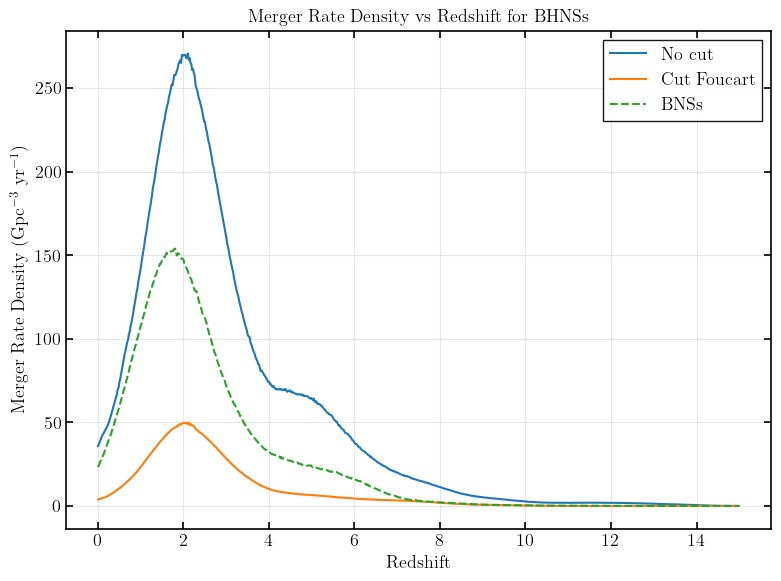

In [31]:
path1 = "/mnt/c/Users/Ludovico/Downloads/MAGGPY/datafiles/populations/MRD/output_sigma0.1/fiducial_delayed_cut/A0.5/BHNSs/_MRD_spread_15Z_40_No_MandF2017_0.1_No_No_0.dat"
path2 = "/mnt/c/Users/Ludovico/Downloads/MAGGPY/datafiles/populations/MRD/output_sigma0.1/fiducial_delayed_cut/A0.5/BHNSs/MRD_spread_15Z_40_No_MandF2017_0.1_No_No_0.dat"

path_bns = "/mnt/c/Users/Ludovico/Downloads/MAGGPY/datafiles/populations/MRD/output_sigma0.1/fiducial_delayed/A0.5/BNSs/MRD_spread_15Z_40_No_MandF2017_0.1_No_No_0.dat"

z_1, mrd_1 = np.loadtxt(path1, unpack=True)
z_2, mrd_2 = np.loadtxt(path2, unpack=True)
z_bns, mrd_bns = np.loadtxt(path_bns, unpack=True)

plt.plot(z_1, mrd_1, label='No cut')
plt.plot(z_2, mrd_2, label='Cut Foucart')
plt.plot(z_bns, mrd_bns, label='BNSs', linestyle='--')
plt.xlabel('Redshift')
plt.ylabel('Merger Rate Density (Gpc$^{-3}$ yr$^{-1}$)')
plt.title('Merger Rate Density vs Redshift for BHNSs')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [2]:
from src.nsbh.init import initialize_combined_simulation, NSBHData
from src.top_hat.montecarlo import (
    create_k_interpolator,
    compute_luminosity_distance,
    simplified_montecarlo,
    apply_detection_cuts,
    score_func_cvm,
    poiss_log,
)
from src.top_hat.geometric_eff import geometric_efficiency_fixed
from src.nsbh.montecarlo import GBM_EFF, FJ_NSBH_FIXED, N_MC_EVENTS

demo_params = {
    "alpha"       : -0.6,
    "beta_s"      : -2.5,
    "n"           : 2.0,
    "theta_c"     : 3.4,
    "theta_v_max" : 10.0,
    "z_model"     : "fiducial_delayed_A0.5",
}

bns_params, nsbh_data, data_dict = initialize_combined_simulation(
    datafiles       = datafiles,
    params          = demo_params,
    size_test       = 2_000,
    nsbh_population = "fiducial_delayed_cut",
    nsbh_alpha      = "A0.5",
)

# Pre-compute shared objects (once, before MCMC)
k_interpolator = create_k_interpolator()
bns_distances  = compute_luminosity_distance(bns_params.z_arr)
nsbh_distances = nsbh_data.distances

print(f"\nBNS:  {len(bns_params.z_arr)} events/yr, z_max = {bns_params.z_arr.max():.2f}")
print(f"NSBH: {len(nsbh_data.z_arr)} events/yr, z_max = {nsbh_data.z_arr.max():.2f}")
print(f"BHNSs/BNSs rate ratio: {len(nsbh_data.z_arr) / len(bns_params.z_arr):.3f}")
print(f"\nObserved yearly rate: {bns_params.yearly_rate:.1f} GRBs/yr")
print(f"Triggered years: {bns_params.triggered_years:.1f}")

Using redshift model: samples_fiducial_delayed_A0.5_BNSs_0.dat with 60187 BNSs.
Computed total merger rate: 60477.4 yr^-1 (local R_0 = 22.7 Gpc^-3 yr^-1) for component BNSs
Generating temporal interpolators... (this may take a moment)
Preparing catalogue with limits: {'F_LIM': 4, 'T90_LIM': 2, 'EP_LIM_UPPER': 10000, 'EP_LIM_LOWER': 50}
Triggered events: 325, Trigger years: 17.50, Yearly rate: 18.58 events/year
Computed total merger rate: 18332.3 yr^-1 (local R_0 = 3.8 Gpc^-3 yr^-1) for component BHNSs
NSBH population: fiducial_delayed_cut / A0.5
  BHNSs local rate R_0 = 3.8 Gpc^-3 yr^-1
  BHNSs total rate     = 18332 yr^-1
  1-year z sample size = 18332

BNS:  60187 events/yr, z_max = 10.86
NSBH: 18332 events/yr, z_max = 10.59
BHNSs/BNSs rate ratio: 0.305

Observed yearly rate: 18.6 GRBs/yr
Triggered years: 17.5


## 2. Universal-Angle Geometric Efficiency

Compare fixed vs lognormal geometric efficiency to see the difference.
For a fixed top-hat jet: $f_b = 1 - \cos(\theta_c)$.

In [3]:
from src.top_hat.montecarlo import create_geometric_efficiency_lognormal_interpolator

geom_eff_ln = create_geometric_efficiency_lognormal_interpolator(sigma_theta_c=0.5)

## 3. Rate Diagnostic Grid — Which (θ_c_bns, θ_c_nsbh, fj_bns) Reproduce the Observed Rate?

Before running MCMC, scan over parameter space to see which combinations of fixed angles and jet fractions give a predicted rate close to the observed GRB rate. This uses only the geometric/rate prefactors (no MC needed).

## 4. Redshift Distributions

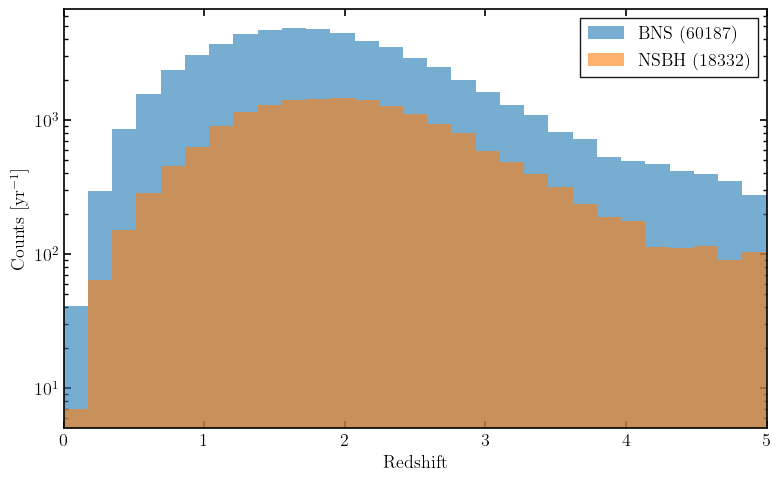

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))  
#N_bns  = len(bns_params.z_arr)
#N_nsbh = len(nsbh_data.z_arr)
#obs_rate_per_yr = bns_params.yearly_rate  # observed GRBs/yr
bins = np.linspace(0, 5, 30)
ax.hist(bns_params.z_arr, bins=bins, alpha=0.6, label=f"BNS ({len(bns_params.z_arr)})", log=True)
ax.hist(nsbh_data.z_arr, bins=bins, alpha=0.6, label=f"NSBH ({len(nsbh_data.z_arr)})", log=True)
ax.set_xlabel("Redshift")
ax.set_ylabel(r"Counts [yr$^{-1}$]")
ax.legend()
ax.set_xlim(0, 5)
plt.tight_layout()
plt.show()

## 5. Universal-Angle Likelihood & MCMC Setup

Define the combined BNS+NSBH log-likelihood using `geometric_efficiency_fixed` instead of the lognormal interpolator.

In [5]:
def log_likelihood_combined_universal(
    thetas, bns_params, nsbh_data,
    bns_distances, nsbh_distances,
    k_interpolator,
    n_events=N_MC_EVENTS,
):
    """
    Joint BNS + NSBH log-likelihood with FIXED opening angles.

    thetas = [A_index, L_L0, L_mu_E, sigma_E,
              theta_c_bns, theta_c_nsbh, fj_bns]
    """
    A_index, L_L0, L_mu_E, sigma_E, theta_c_bns, theta_c_nsbh, fj_bns = thetas
    grb_thetas = [A_index, L_L0, L_mu_E, sigma_E]
    triggered_years = bns_params.triggered_years

    # ── Fixed geometric efficiencies ────────────────────────────────────────
    geom_eff_bns  = geometric_efficiency_fixed(theta_c_bns)
    geom_eff_nsbh = geometric_efficiency_fixed(theta_c_nsbh)

    epsilon_bns  = geom_eff_bns  * fj_bns
    epsilon_nsbh = geom_eff_nsbh * FJ_NSBH_FIXED

    # ── Expected intrinsic rates ────────────────────────────────────────────
    intrinsic_bns  = epsilon_bns  * len(bns_params.z_arr) * GBM_EFF
    intrinsic_nsbh = epsilon_nsbh * len(nsbh_data.z_arr)  * GBM_EFF

    # ── BNS Monte Carlo ────────────────────────────────────────────────────
    bns_results = simplified_montecarlo(
        grb_thetas, n_events, bns_params, bns_distances, k_interpolator,
    )
    bns_trig, bns_analysis = apply_detection_cuts(
        bns_results["p_flux"], bns_results["E_p_obs"],
    )

    # ── NSBH Monte Carlo ───────────────────────────────────────────────────
    nsbh_results = simplified_montecarlo(
        grb_thetas, n_events, nsbh_data, nsbh_distances, k_interpolator,
        rng=bns_params.rng,
    )
    nsbh_trig, nsbh_analysis = apply_detection_cuts(
        nsbh_results["p_flux"], nsbh_results["E_p_obs"],
    )

    # ── Physics efficiencies ───────────────────────────────────────────────
    phys_eff_bns  = np.sum(bns_trig)  / n_events
    phys_eff_nsbh = np.sum(nsbh_trig) / n_events

    # ── Merge detections ───────────────────────────────────────────────────
    pflux_det = np.concatenate([
        bns_results["p_flux"][bns_analysis],
        nsbh_results["p_flux"][nsbh_analysis],
    ])
    epeak_det = np.concatenate([
        bns_results["E_p_obs"][bns_analysis],
        nsbh_results["E_p_obs"][nsbh_analysis],
    ])

    if len(pflux_det) <= 3:
        return -np.inf, -np.inf, -np.inf, -np.inf, 0.0

    # ── Shape likelihood ───────────────────────────────────────────────────
    logL_pflux = score_func_cvm(pflux_det, bns_params.pflux_data, bns_params.rng)
    logL_epeak = score_func_cvm(epeak_det, bns_params.epeak_data, bns_params.rng)

    # ── Poisson rate ───────────────────────────────────────────────────────
    predicted_bns  = intrinsic_bns  * triggered_years * phys_eff_bns
    predicted_nsbh = intrinsic_nsbh * triggered_years * phys_eff_nsbh
    predicted_total = predicted_bns + predicted_nsbh
    observed_total  = bns_params.yearly_rate * triggered_years

    if predicted_total <= 0:
        return -np.inf, -np.inf, -np.inf, -np.inf, 0.0

    logL_poisson = poiss_log(k=observed_total, mu=predicted_total)

    return (
        logL_pflux + logL_epeak + logL_poisson,
        logL_pflux, logL_epeak, logL_poisson,
        (phys_eff_bns + phys_eff_nsbh) / 2,
    )


def generate_combined_population_universal(
    thetas, bns_params, nsbh_data,
    k_interpolator, n_events=N_MC_EVENTS, seed=None,
):
    """Generate a combined BNS+NSBH population for PPCs (fixed angle)."""
    A_index, L_L0, L_mu_E, sigma_E, theta_c_bns, theta_c_nsbh, fj_bns = thetas
    grb_thetas = [A_index, L_L0, L_mu_E, sigma_E]

    if seed is not None:
        bns_params.rng = np.random.default_rng(seed)

    bns_dist  = compute_luminosity_distance(bns_params.z_arr)
    nsbh_dist = nsbh_data.distances

    bns_results = simplified_montecarlo(
        grb_thetas, n_events, bns_params, bns_dist, k_interpolator,
    )
    _, bns_analysis = apply_detection_cuts(bns_results["p_flux"], bns_results["E_p_obs"])

    nsbh_results = simplified_montecarlo(
        grb_thetas, n_events, nsbh_data, nsbh_dist, k_interpolator,
        rng=bns_params.rng,
    )
    _, nsbh_analysis = apply_detection_cuts(nsbh_results["p_flux"], nsbh_results["E_p_obs"])

    n_bns  = int(np.sum(bns_analysis))
    n_nsbh = int(np.sum(nsbh_analysis))
    if n_bns + n_nsbh == 0:
        return None

    return {
        "pflux"      : np.concatenate([bns_results["p_flux"][bns_analysis],
                                       nsbh_results["p_flux"][nsbh_analysis]]),
        "epeak"      : np.concatenate([bns_results["E_p_obs"][bns_analysis],
                                       nsbh_results["E_p_obs"][nsbh_analysis]]),
        "z_det"      : np.concatenate([bns_results["z_arr"][bns_analysis],
                                       nsbh_results["z_arr"][nsbh_analysis]]),
        "origin"     : np.concatenate([np.zeros(n_bns, dtype=int),
                                       np.ones(n_nsbh, dtype=int)]),
        "n_detected" : n_bns + n_nsbh,
        "n_bns_det"  : n_bns,
        "n_nsbh_det" : n_nsbh,
    }

print("Universal-angle likelihood defined.")

Universal-angle likelihood defined.


## 6. Quick Sanity Check — Single Population Draw

In [6]:
# Test with reasonable parameters
# [A_index, L_L0, L_mu_E, sigma_E, theta_c_bns, theta_c_nsbh, fj_bns]
thetas_test = [2.5, 2.5, 2.7, 0.35, 7.0, 7.0, 0.5]
N_SIM = 10_000
pop = generate_combined_population_universal(
    thetas_test, bns_params, nsbh_data,
    k_interpolator, n_events=N_SIM, seed=42,
)

N_bns  = len(bns_params.z_arr)
N_nsbh = len(nsbh_data.z_arr)

if pop is not None:
    theta_c_bns_t, theta_c_nsbh_t, fj_bns_t = thetas_test[4], thetas_test[5], thetas_test[6]
    fb_bns_t  = geometric_efficiency_fixed(theta_c_bns_t)
    fb_nsbh_t = geometric_efficiency_fixed(theta_c_nsbh_t)

    phys_eff = pop["n_detected"] / N_SIM
    pred_bns  = fb_bns_t * fj_bns_t * N_bns * GBM_EFF * bns_params.triggered_years * (pop["n_bns_det"] / N_SIM)
    pred_nsbh = fb_nsbh_t * FJ_NSBH_FIXED * N_nsbh * GBM_EFF * bns_params.triggered_years * (pop["n_nsbh_det"] / N_SIM)

    print(f"MC detected: {pop['n_detected']}  (BNS: {pop['n_bns_det']}, NSBH: {pop['n_nsbh_det']})")
    print(f"NSBH fraction of detections: {pop['n_nsbh_det'] / max(pop['n_detected'], 1):.2%}")
    print(f"\nfb_bns  = {fb_bns_t:.5f}  (θ={theta_c_bns_t}°)")
    print(f"fb_nsbh = {fb_nsbh_t:.5f}  (θ={theta_c_nsbh_t}°)")
    print(f"\nPredicted BNS  rate: {pred_bns:.1f} over {bns_params.triggered_years:.1f} yr")
    print(f"Predicted NSBH rate: {pred_nsbh:.1f} over {bns_params.triggered_years:.1f} yr")
    print(f"Predicted total:     {pred_bns + pred_nsbh:.1f}")
    print(f"Observed total:      {bns_params.yearly_rate * bns_params.triggered_years:.1f}")
else:
    print("No detections.")

MC detected: 1389  (BNS: 845, NSBH: 544)
NSBH fraction of detections: 39.16%

fb_bns  = 0.00745  (θ=7.0°)
fb_nsbh = 0.00745  (θ=7.0°)

Predicted BNS  rate: 199.0 over 17.5 yr
Predicted NSBH rate: 78.0 over 17.5 yr
Predicted total:     277.0
Observed total:      325.0


## 7. MCMC — Universal Angle

Run `emcee` with the 7-dim parameter vector using fixed geometric efficiency.

| Parameter | Prior range |
|-----------|-------------|
| `A_index` | (1.5, 12) |
| `L_L0` | (−2, 7) |
| `L_mu_E` | (0.1, 7) |
| `sigma_E` | (0, 2.5) |
| `theta_c_bns` | (1, 25) deg |
| `theta_c_nsbh` | (1, 25) deg |
| `fj_bns` | (0, 10) |

In [7]:
import emcee
from math import inf
import src.init

from src.top_hat.montecarlo import create_move_strategy, run_mcmc, check_and_resume_mcmc

# ── Parameters ──────────────────────────────────────────────────────────────
N_PARAMS    = 7
N_WALKERS   = 20
N_STEPS     = 35_000
PARAM_NAMES = [
    r"$k$", r"$\log_{10}(L_0)$", r"$\log_{10}(\mu_E)$", r"$\sigma_E$",
    r"$\theta_{c}^{\mathrm{BNS}}$",
    r"$\theta_{c}^{\mathrm{NSBH}}$",
    r"$f_j^{\mathrm{BNS}}$",
]

# ── Prior (flat, same bounds as lognormal version) ──────────────────────────
def log_prior_universal(thetas):
    A_index, L_L0, L_mu_E, sigma_E, theta_c_bns, theta_c_nsbh, fj_bns = thetas

    if not (1.5 < A_index       < 12)  : return -inf
    if not (-2  < L_L0          < 7)   : return -inf
    if not (0.1 < L_mu_E        < 7)   : return -inf
    if not (0   < sigma_E       < 2.5) : return -inf
    if not (1   < theta_c_bns   < 25)  : return -inf
    if not (1   < theta_c_nsbh  < 50)  : return -inf
    if not (0   < fj_bns        < FJ_MAX)  : return -inf
    return 0.0

# ── Walker initialisation ──────────────────────────────────────────────────
def initialize_walkers_universal(n_walkers):
    rng = np.random.default_rng(42)
    return np.column_stack([
        rng.uniform(2,   3,    n_walkers),   # A_index
        rng.uniform(2,   4,    n_walkers),   # L_L0
        rng.uniform(2,   4,    n_walkers),   # L_mu_E
        rng.uniform(0.2, 1,    n_walkers),   # sigma_E
        rng.uniform(5,   10,   n_walkers),   # theta_c_bns
        rng.uniform(5,   10,   n_walkers),   # theta_c_nsbh
        rng.uniform(0.3, 0.9 * FJ_MAX,  n_walkers),   # fj_bns
    ])

# ── Output directory ────────────────────────────────────────────────────────
output_dir = src.init.create_run_dir(f"NSBH_combined_universal_SND_A0_5_{FJ_MAX}", output_files_default="Output_files")

print(f"N_PARAMS  = {N_PARAMS}")
print(f"N_WALKERS = {N_WALKERS}")
print(f"N_STEPS   = {N_STEPS}")
print(f"fj_nsbh   = {FJ_NSBH_FIXED} (fixed)")
print(f"Geom eff  = FIXED (1 - cos θ_c)")
print(f"Output    → {output_dir}")

Loading existing directory  : Output_files/NSBH_combined_universal_SND_A0_5_1
N_PARAMS  = 7
N_WALKERS = 20
N_STEPS   = 35000
fj_nsbh   = 1 (fixed)
Geom eff  = FIXED (1 - cos θ_c)
Output    → Output_files/NSBH_combined_universal_SND_A0_5_1


In [8]:
# ── Build log-probability function (closure over data) ──────────────────────
def log_probability_universal(thetas):
    lp = log_prior_universal(thetas)
    if not np.isfinite(lp):
        return -np.inf, 0.0, 0.0, 0.0, 0.0

    ll = log_likelihood_combined_universal(
        thetas, bns_params, nsbh_data,
        bns_distances, nsbh_distances,
        k_interpolator, n_events=N_MC_EVENTS,
    )
    if not np.isfinite(ll[0]):
        return -np.inf, 0.0, 0.0, 0.0, 0.0

    return lp + ll[0], ll[1], ll[2], ll[3], ll[4]

# ── Resume or start fresh ──────────────────────────────────────────────────
initial_pos, n_steps_remaining, backend = check_and_resume_mcmc(
    filename                = output_dir / "emcee.h5",
    n_steps                 = N_STEPS,
    initialize_walkers_func = initialize_walkers_universal,
    n_walkers               = N_WALKERS,
)

# ── Run MCMC ────────────────────────────────────────────────────────────────
sampler = run_mcmc(
    log_probability_func = log_probability_universal,
    initial_walkers      = initial_pos,
    n_iterations         = n_steps_remaining,
    n_walkers            = N_WALKERS,
    n_params             = N_PARAMS,
    backend              = backend,
    blobs_dtype          = [
        ("l_pflux", float),
        ("l_epeak", float),
        ("l_poiss", float),
        ("l_eff",   float),
    ],
)

print(f"\nMCMC complete — {backend.iteration} steps stored.")

Already completed this run


0it [00:00, ?it/s]


MCMC complete — 35000 steps stored.


## 8. MCMC Diagnostics

Total steps: 35000
After burn-in (11666) + thin (15): 31100 samples
Acceptance fraction: 0.037


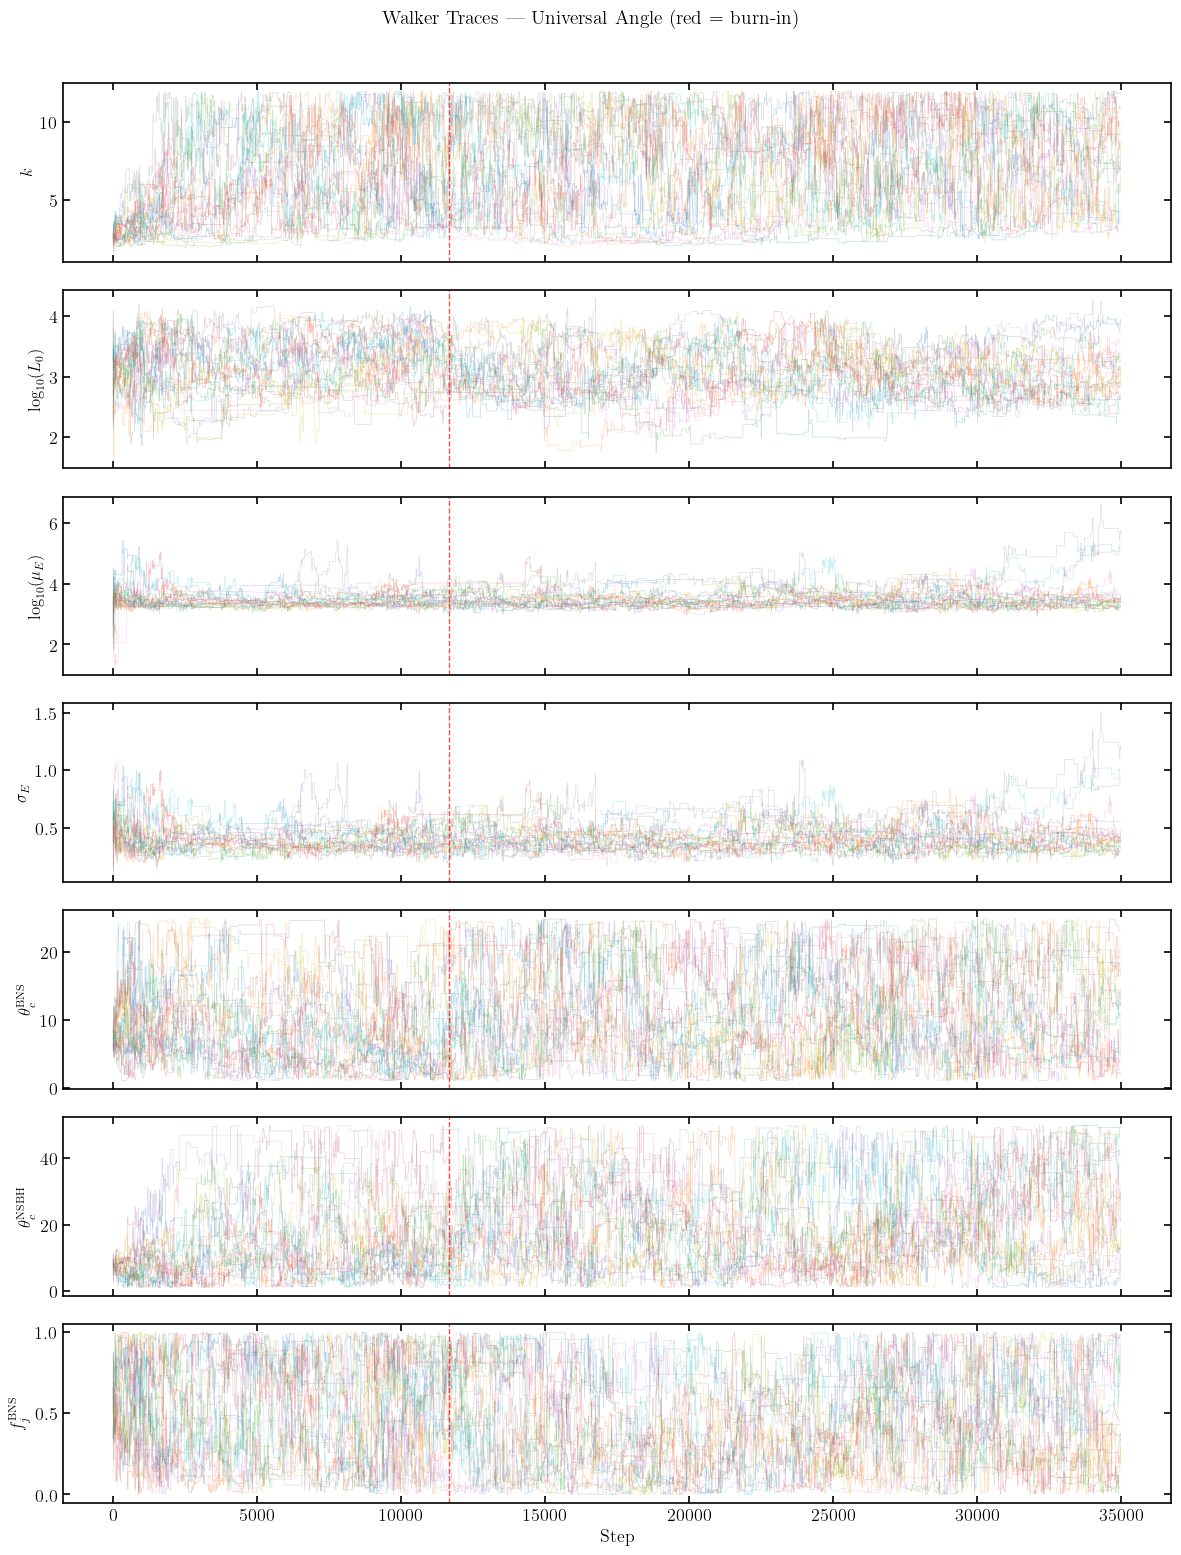

In [9]:
# ── Load backend (can re-run this cell independently) ───────────────────────
backend_ua = emcee.backends.HDFBackend(output_dir / "emcee.h5")

burn_in = N_STEPS // 3
thin    = 15

chain = backend_ua.get_chain(discard=burn_in, thin=thin, flat=False)
flat_samples = backend_ua.get_chain(discard=burn_in, thin=thin, flat=True)

print(f"Total steps: {backend_ua.iteration}")
print(f"After burn-in ({burn_in}) + thin ({thin}): {flat_samples.shape[0]} samples")
print(f"Acceptance fraction: {np.mean(backend_ua.accepted / backend_ua.iteration):.3f}")

# ── Trace plots ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(N_PARAMS, 1, figsize=(12, 2.2 * N_PARAMS), sharex=True)
full_chain = backend_ua.get_chain(flat=False)

for i, (ax, label) in enumerate(zip(axes, PARAM_NAMES)):
    for w in range(full_chain.shape[1]):
        ax.plot(full_chain[:, w, i], alpha=0.25, lw=0.5)
    ax.set_ylabel(label, fontsize=12)
    ax.axvline(burn_in, color='red', ls='--', lw=1, alpha=0.7)

axes[-1].set_xlabel("Step")
fig.suptitle("Walker Traces — Universal Angle (red = burn-in)", fontsize=14, y=1.01)
plt.tight_layout()
fig.savefig(output_dir / "trace_plot.pdf", dpi=150, bbox_inches='tight')
plt.show()

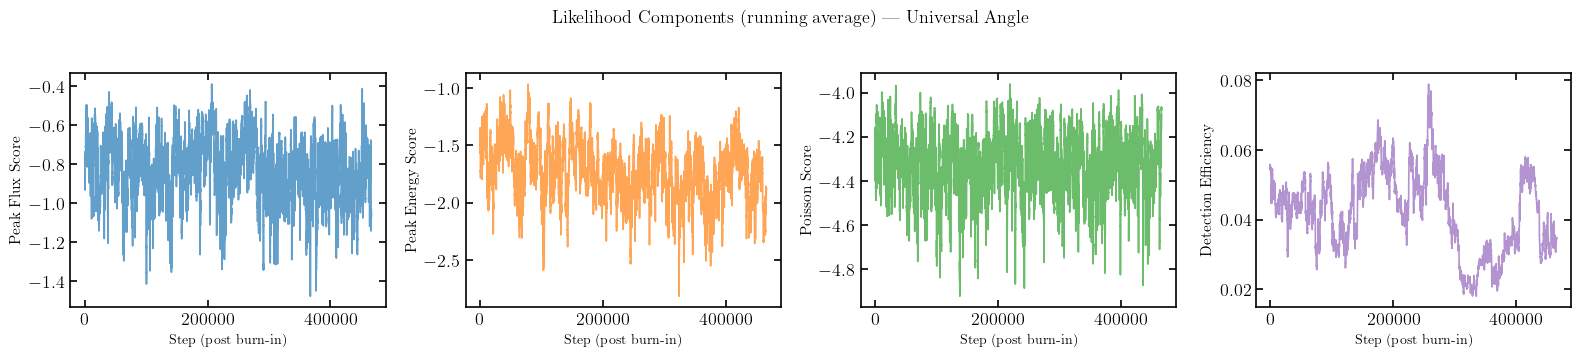

In [10]:
# ── Likelihood component evolution ──────────────────────────────────────────
blobs = backend_ua.get_blobs(discard=burn_in, flat=True)
window = 200

def running_avg(arr, w=window):
    return np.convolve(arr, np.ones(w)/w, mode='valid')

fig, axs = plt.subplots(1, 4, figsize=(16, 3.5))
titles = ['Peak Flux Score', 'Peak Energy Score', 'Poisson Score', 'Detection Efficiency']
colors = plt.cm.tab10(np.linspace(0, 0.4, 4))

for ax, name, title, color in zip(axs, blobs.dtype.names, titles, colors):
    data = running_avg(blobs[name])
    ax.plot(data, color=color, alpha=0.7, lw=1.2)
    ax.set_ylabel(title, fontsize=11)
    ax.set_xlabel("Step (post burn-in)", fontsize=10)

plt.suptitle("Likelihood Components (running average) — Universal Angle", fontsize=13, y=1.02)
plt.tight_layout()
fig.savefig(output_dir / "likelihood_evolution.pdf", dpi=150, bbox_inches='tight')
plt.show()

## 9. Corner Plots

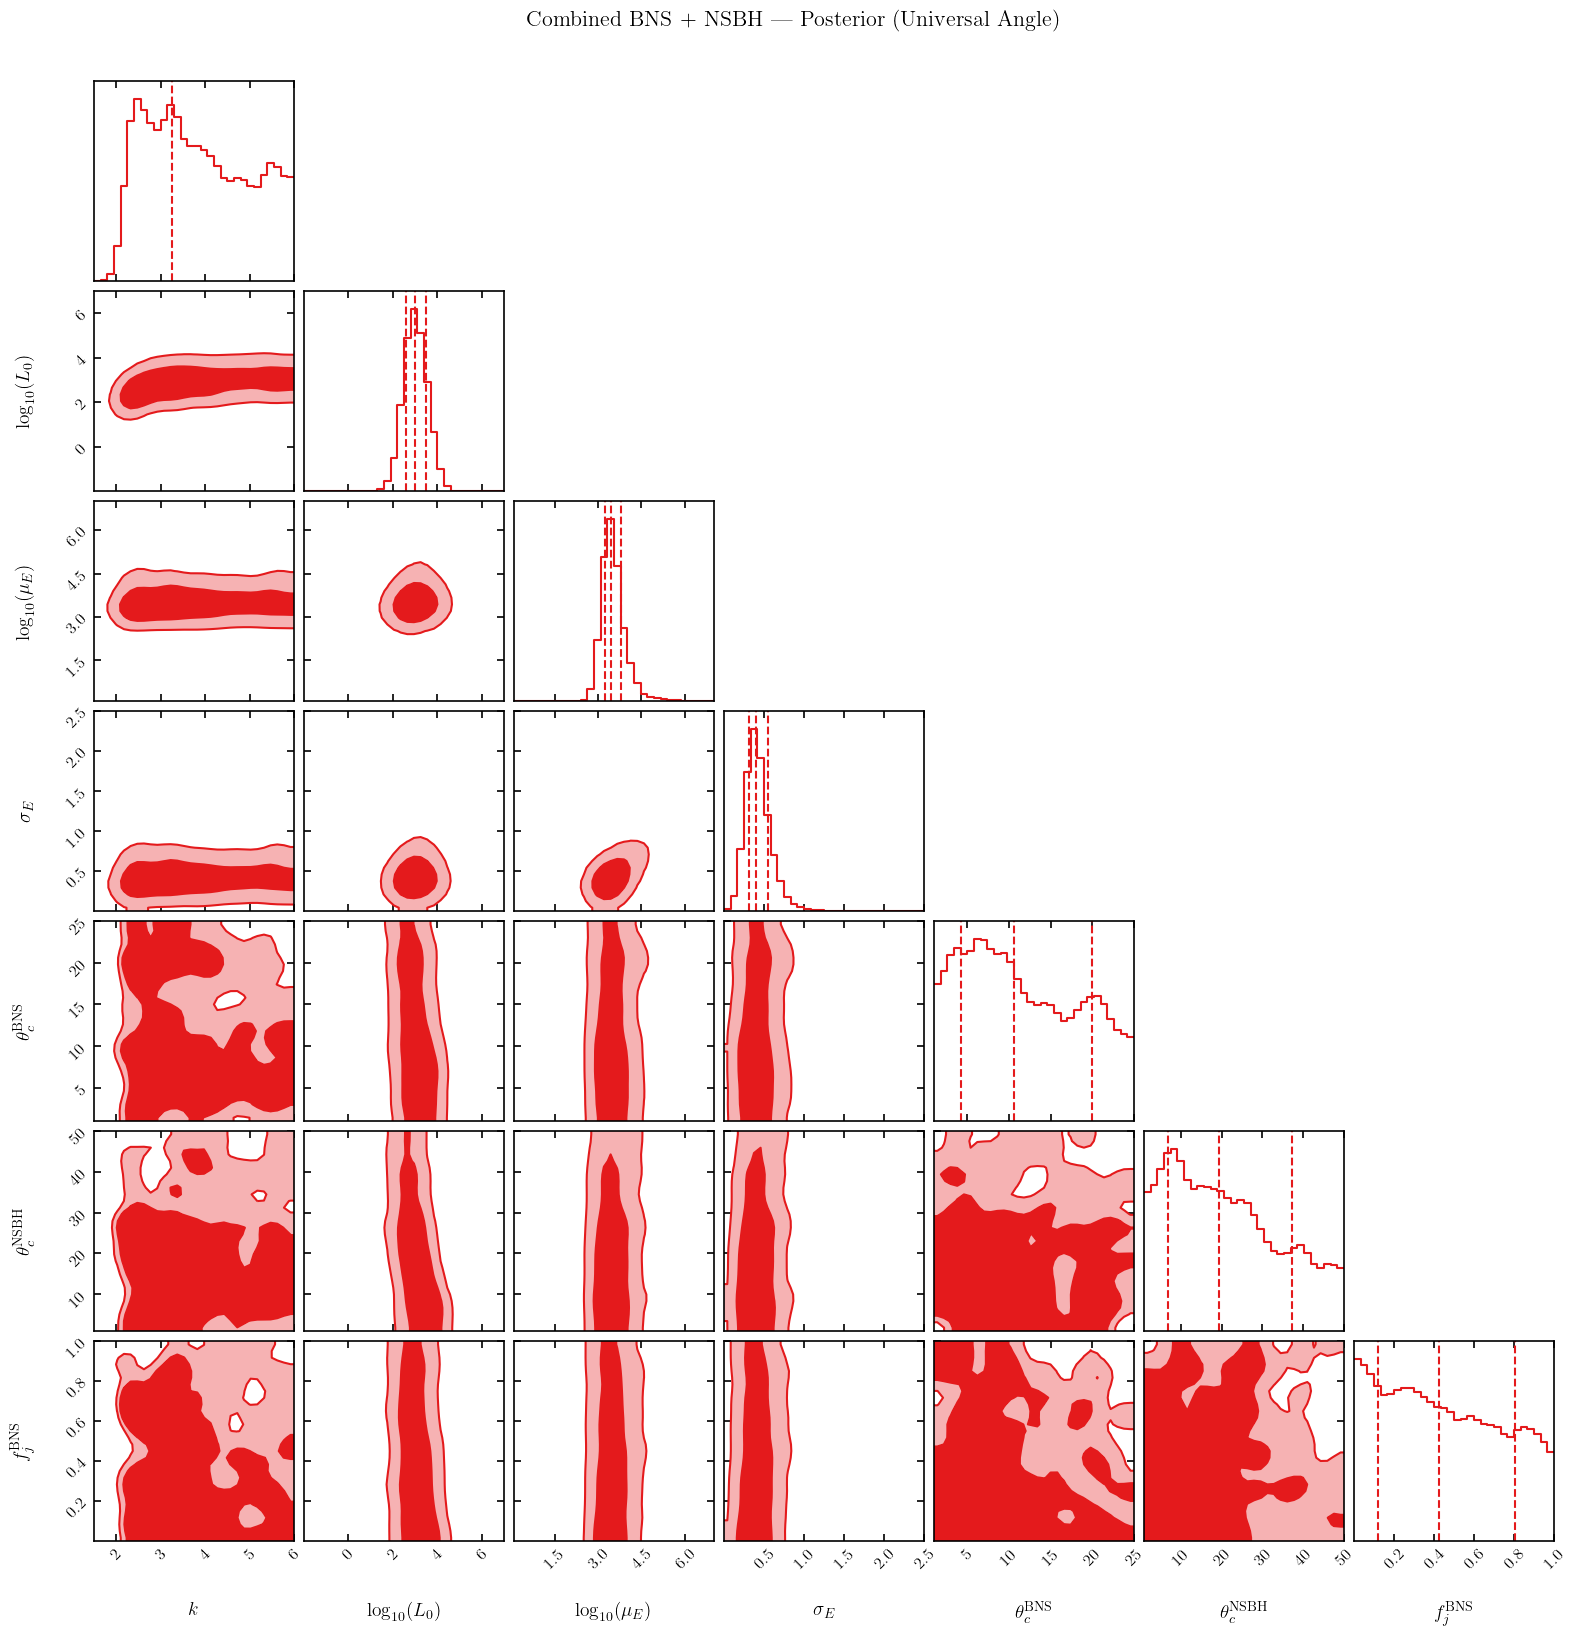


Parameter estimates (median ± 1σ):
                                  $k$  =  6.918  [3.245, 10.362]
                     $\log_{10}(L_0)$  =  2.995  [2.608, 3.495]
                   $\log_{10}(\mu_E)$  =  3.436  [3.256, 3.796]
                           $\sigma_E$  =  0.400  [0.313, 0.555]
          $\theta_{c}^{\mathrm{BNS}}$  =  10.592  [4.197, 19.973]
         $\theta_{c}^{\mathrm{NSBH}}$  =  19.417  [6.974, 37.314]
                 $f_j^{\mathrm{BNS}}$  =  0.428  [0.119, 0.805]


In [32]:
import corner
import matplotlib.colors as mcolors

ranges = [
    (1.5, 6),    # A_index
    (-2, 7),     # L_L0
    (0.1, 7),    # L_mu_E
    (0, 2.5),    # sigma_E
    (1, 25),     # theta_c_bns
    (1, 50),     # theta_c_nsbh
    (0, FJ_MAX),     # fj_bns
]

col = [mcolors.to_hex(c) for c in plt.cm.Set1(np.linspace(0, 1, 9))]

fig = corner.corner(
    flat_samples,
    labels=PARAM_NAMES,
    range=ranges,
    quantiles=[0.16, 0.5, 0.84],
    show_titles=False,
    label_kwargs={"fontsize": 14},
    levels=[0.68, 0.95],
    plot_datapoints=False,
    plot_density=False,
    fill_contours=True,
    bins=30,
    smooth=1.5,
    smooth1d=1.0,
    color=col[0],
)

for ax in fig.get_axes():
    ax.grid(False)
    ax.tick_params(labelsize=12)

fig.suptitle("Combined BNS + NSBH — Posterior (Universal Angle)", fontsize=16, y=1.02)
fig.savefig(output_dir / "corner_plot.pdf", dpi=300, bbox_inches='tight')
plt.show()

# ── Summary table ───────────────────────────────────────────────────────────
print("\nParameter estimates (median ± 1σ):")
print("=" * 60)
for i, label in enumerate(PARAM_NAMES):
    lo, med, hi = np.percentile(flat_samples[:, i], [16, 50, 84])
    print(f"  {label:>35s}  =  {med:.3f}  [{lo:.3f}, {hi:.3f}]")

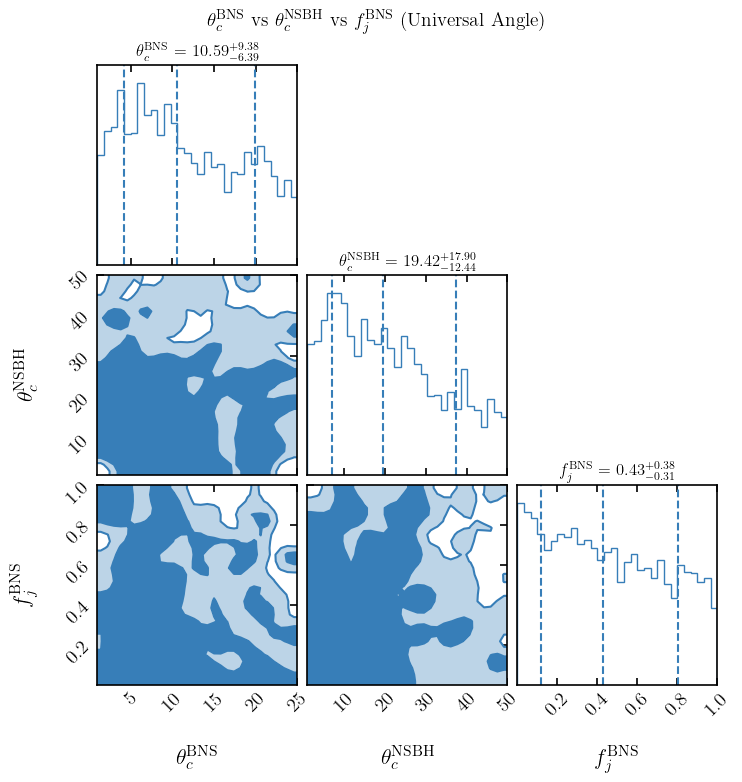

In [12]:
# ── Corner plot: last 3 parameters only (θ_c_bns, θ_c_nsbh, fj_bns) ───────
#change fj range to 0-1
ranges[-1] = (0, 1)

fig = corner.corner(
    flat_samples[:, 4:],
    labels=PARAM_NAMES[4:],
    range=ranges[4:],
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs={"fontsize": 16},
    levels=[0.68, 0.95],
    plot_datapoints=False,
    plot_density=False,
    fill_contours=True,
    bins=30,
    smooth=1.2,
    color=col[1],
)

for ax in fig.get_axes():
    ax.tick_params(labelsize=14)

fig.suptitle(r"$\theta_c^{\rm BNS}$ vs $\theta_c^{\rm NSBH}$ vs $f_j^{\rm BNS}$ (Universal Angle)", fontsize=14, y=1.02)
fig.savefig(output_dir / "corner_last3.pdf", dpi=300, bbox_inches='tight')
plt.show()

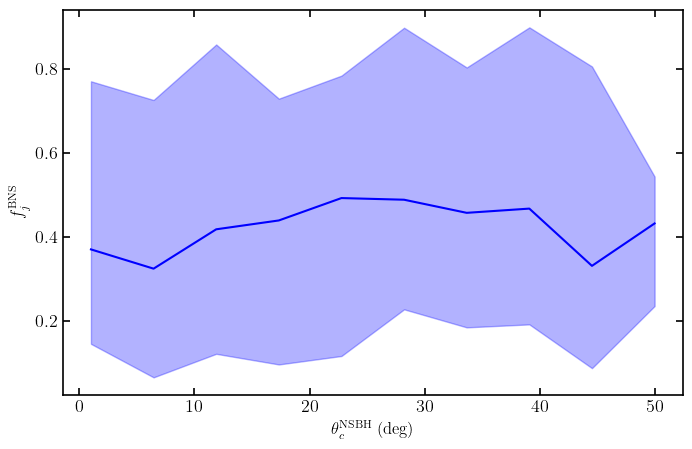

In [13]:
# as a function of theta_c plot median and 90% C.I fj
#theta_c_NSBH_vals = np.linspace(1, 50, 10)
#1 deg spacing
theta_c_NSBH_vals = np.linspace(1, 50, 10)
#np.arange(1, 10, 1)

fj_bns_medians = []
fj_bns_lows = []
fj_bns_highs = []
for theta_c_NSBH_Test in theta_c_NSBH_vals:
    mask = (flat_samples[:, 5] >= theta_c_NSBH_Test - 1) & (flat_samples[:, 5] <= theta_c_NSBH_Test + 1)
    fj_bns_subset = flat_samples[mask, 6]
    if len(fj_bns_subset) > 0:
        fj_bns_medians.append(np.median(fj_bns_subset))
        fj_bns_lows.append(np.percentile(fj_bns_subset, 16))
        fj_bns_highs.append(np.percentile(fj_bns_subset, 84))
    else:
        fj_bns_medians.append(np.nan)
        fj_bns_lows.append(np.nan)
        fj_bns_highs.append(np.nan)

plt.figure(figsize=(8, 5))
plt.plot(theta_c_NSBH_vals, fj_bns_medians, label='Median $f_j^{BNS}$', color='blue')
plt.fill_between(theta_c_NSBH_vals, fj_bns_lows, fj_bns_highs, color='blue', alpha=0.3, label='16-84% CI')
plt.xlabel(r'$\theta_c^{\text{NSBH}}$ (deg)', fontsize=12)
plt.ylabel(r'$f_j^{\text{BNS}}$', fontsize=12)
plt.show()

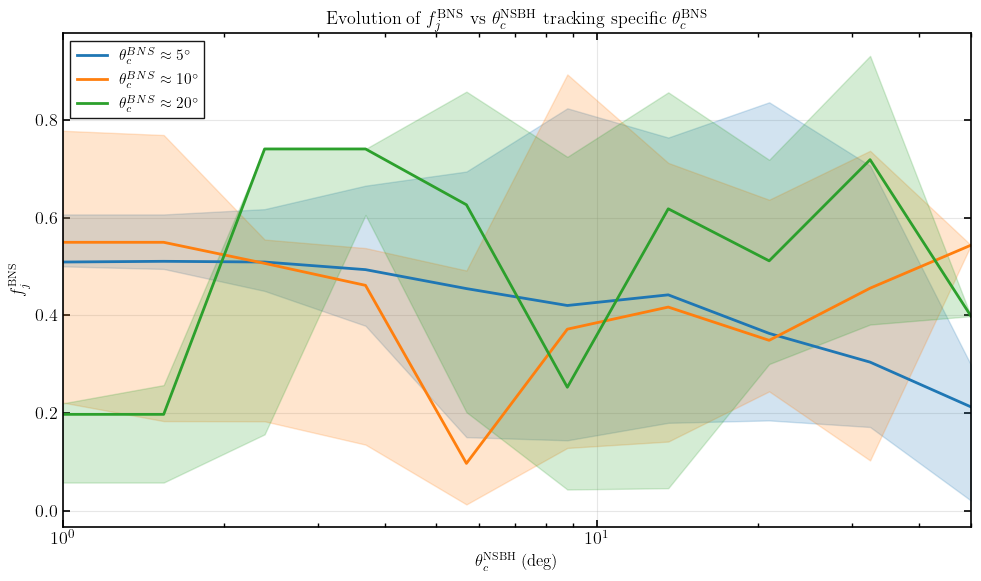

In [14]:
# Fixed target BNS angles
theta_c_BNS_targets = [5, 10, 20]
colors = ['C0', 'C1', 'C2']  # Colors for each BNS angle line

# Evolve over NSBH angles
theta_c_NSBH_vals = np.logspace(np.log10(1), np.log10(50), 10)
#@np.linspace(1, 50, 5)
#np.arange(1, 51, 1)

plt.figure(figsize=(10, 6))

for target, color in zip(theta_c_BNS_targets, colors):
    fj_bns_medians = []
    fj_bns_lows = []
    fj_bns_highs = []
    
    for theta_c_NSBH_Test in theta_c_NSBH_vals:
        # Mask on NSBH angle (+/- 1 deg) AND target BNS angle (+/- 1 deg)
        mask = (flat_samples[:, 5] >= theta_c_NSBH_Test - 1) & \
               (flat_samples[:, 5] <= theta_c_NSBH_Test + 1) & \
               (flat_samples[:, 4] >= target - 1) & \
               (flat_samples[:, 4] <= target + 1)
        
        fj_bns_subset = flat_samples[mask, 6]
        
        if len(fj_bns_subset) > 0:
            fj_bns_medians.append(np.median(fj_bns_subset))
            fj_bns_lows.append(np.percentile(fj_bns_subset, 16))
            fj_bns_highs.append(np.percentile(fj_bns_subset, 84))
        else:
            fj_bns_medians.append(np.nan)
            fj_bns_lows.append(np.nan)
            fj_bns_highs.append(np.nan)
            
    # Plot the line and CI for this specific BNS target angle
    plt.plot(theta_c_NSBH_vals, fj_bns_medians, label=rf'$\theta_c^{{BNS}} \approx {target}^\circ$', color=color, lw=2)
    plt.fill_between(theta_c_NSBH_vals, fj_bns_lows, fj_bns_highs, color=color, alpha=0.2)

plt.xlabel(r'$\theta_c^{\text{NSBH}}$ (deg)', fontsize=12)
plt.ylabel(r'$f_j^{\text{BNS}}$', fontsize=12)
plt.title(r'Evolution of $f_j^{\text{BNS}}$ vs $\theta_c^{\text{NSBH}}$ tracking specific $\theta_c^{\text{BNS}}$', fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xlim(1, 50)
plt.xscale('log')
plt.tight_layout()
plt.show()

## 10. CDF Comparison & Rate Distribution

In [15]:
n_ppc = 200
ppc_indices = np.random.default_rng(0).integers(0, len(flat_samples), n_ppc)

pflux_all, epeak_all, rates_all = [], [], []
nsbh_fracs = []

for idx in ppc_indices:
    theta = flat_samples[idx]
    A_index, L_L0, L_mu_E, sigma_E, theta_c_bns, theta_c_nsbh, fj_bns = theta

    n_all = 10_000
    pop = generate_combined_population_universal(
        theta, bns_params, nsbh_data,
        k_interpolator, n_events=n_all, seed=int(idx),
    )
    if pop is None:
        continue

    pflux_all.append(pop["pflux"])
    epeak_all.append(pop["epeak"])
    nsbh_fracs.append(pop["n_nsbh_det"] / max(pop["n_detected"], 1))

    # Predicted rate using fixed geometric efficiency
    fb_bns  = geometric_efficiency_fixed(theta_c_bns)
    fb_nsbh = geometric_efficiency_fixed(theta_c_nsbh)
    #trig_frac = pop["n_detected"] / n_all

    phys_eff_bns  = pop["n_bns_det"]  / n_all
    phys_eff_nsbh = pop["n_nsbh_det"] / n_all

    rate_bns  = fb_bns  * fj_bns * len(bns_params.z_arr) * GBM_EFF * phys_eff_bns
    rate_nsbh = fb_nsbh * FJ_NSBH_FIXED * len(nsbh_data.z_arr) * GBM_EFF * phys_eff_nsbh
    rates_all.append(rate_bns + rate_nsbh)

print(f"Generated {len(pflux_all)} PPC populations")

Generated 200 PPC populations


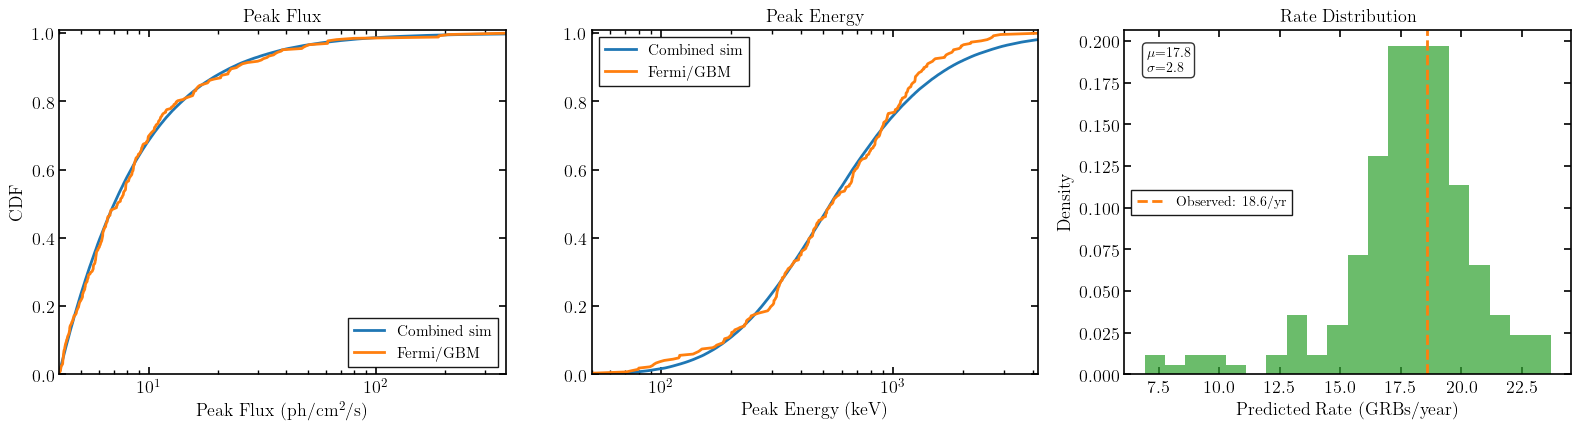

In [16]:
def ecdf(data):
    x = np.sort(data)
    return x, np.arange(1, len(x) + 1) / len(x)

fig, axs = plt.subplots(1, 3, figsize=(16, 4.5))

# Peak Flux CDF
pflux_sim = np.concatenate(pflux_all)
x_sim, cdf_sim = ecdf(pflux_sim)
x_obs, cdf_obs = ecdf(bns_params.pflux_data)

axs[0].plot(x_sim, cdf_sim, color='#1f77b4', lw=2, label='Combined sim')
axs[0].plot(x_obs, cdf_obs, color='#ff7f0e', lw=2, label='Fermi/GBM')
axs[0].set(xlabel=r'Peak Flux (ph/cm$^2$/s)', ylabel='CDF', xscale='log',
           xlim=(4, bns_params.pflux_data.max()), ylim=(0, 1.01))
axs[0].legend(fontsize=11)
axs[0].set_title("Peak Flux")

# Peak Energy CDF
epeak_sim = np.concatenate(epeak_all)
x_sim_e, cdf_sim_e = ecdf(epeak_sim)
x_obs_e, cdf_obs_e = ecdf(bns_params.epeak_data)

axs[1].plot(x_sim_e, cdf_sim_e, color='#1f77b4', lw=2, label='Combined sim')
axs[1].plot(x_obs_e, cdf_obs_e, color='#ff7f0e', lw=2, label='Fermi/GBM')
axs[1].set(xlabel=r'Peak Energy (keV)', xscale='log',
           xlim=(50, bns_params.epeak_data.max()), ylim=(0, 1.01))
axs[1].legend(fontsize=11)
axs[1].set_title("Peak Energy")

# Rate distribution
axs[2].hist(rates_all, bins=20, alpha=0.7, color='#2ca02c', density=True)
axs[2].axvline(bns_params.yearly_rate, color='#ff7f0e', ls='--', lw=2,
               label=f'Observed: {bns_params.yearly_rate:.1f}/yr')
axs[2].set(xlabel='Predicted Rate (GRBs/year)', ylabel='Density')
axs[2].text(0.05, 0.95,
            f'$\\mu$={np.mean(rates_all):.1f}\n$\\sigma$={np.std(rates_all):.1f}',
            transform=axs[2].transAxes, va='top', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
axs[2].legend(fontsize=10)
axs[2].set_title("Rate Distribution")

plt.tight_layout()
fig.savefig(output_dir / "cdf_comparison.pdf", dpi=300, bbox_inches='tight')
plt.show()

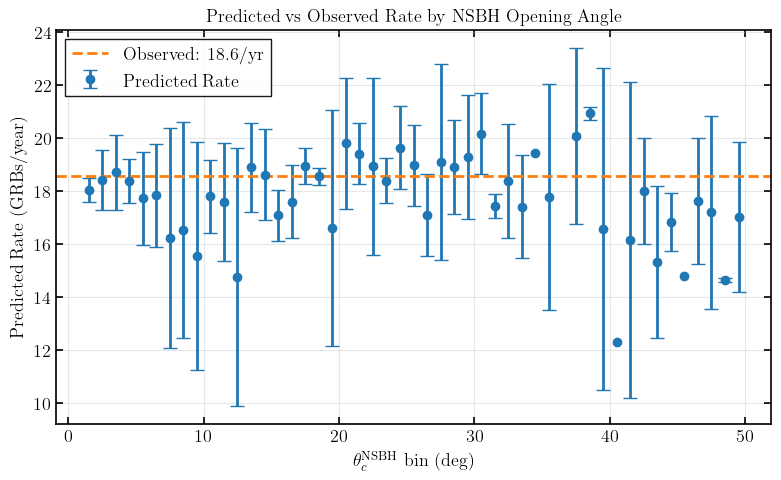

In [17]:
import pandas as pd

# Extract theta_c_nsbh for the samples we used in the PPC
theta_c_nsbh_ppc = flat_samples[ppc_indices, 5]

# Create a DataFrame to easily group and compute stats
df_rates = pd.DataFrame({
    'theta_c_nsbh': theta_c_nsbh_ppc,
    'rate': rates_all
})

# Bin in 1-degree intervals (floor gives the lower edge of the bin)
df_rates['theta_bin'] = np.floor(df_rates['theta_c_nsbh']).astype(int)

# Calculate mean and standard deviation of the rate for each 1-degree bin
grouped = df_rates.groupby('theta_bin')['rate'].agg(['mean', 'std', 'count']).reset_index()

fig, ax = plt.subplots(figsize=(8, 5))

# Plot the predicted rates per bin
ax.errorbar(grouped['theta_bin'] + 0.5, grouped['mean'], yerr=grouped['std'], 
            fmt='o', color='#1f77b4', lw=2, capsize=5, label='Predicted Rate')

# Plot the observed rate
ax.axhline(bns_params.yearly_rate, color='#ff7f0e', ls='--', lw=2, 
           label=f'Observed: {bns_params.yearly_rate:.1f}/yr')

ax.set(xlabel=r"$\theta_c^{\rm NSBH}$ bin (deg)", 
       ylabel="Predicted Rate (GRBs/year)")
ax.set_title("Predicted vs Observed Rate by NSBH Opening Angle")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(output_dir / "rate_vs_NSBH_angle.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [18]:
1/0

ZeroDivisionError: division by zero

## 11. NSBH Contribution Analysis

Key diagnostic: what is the **posterior distribution of the BNS rate** and does adding NSBH shift it away from the observed value?

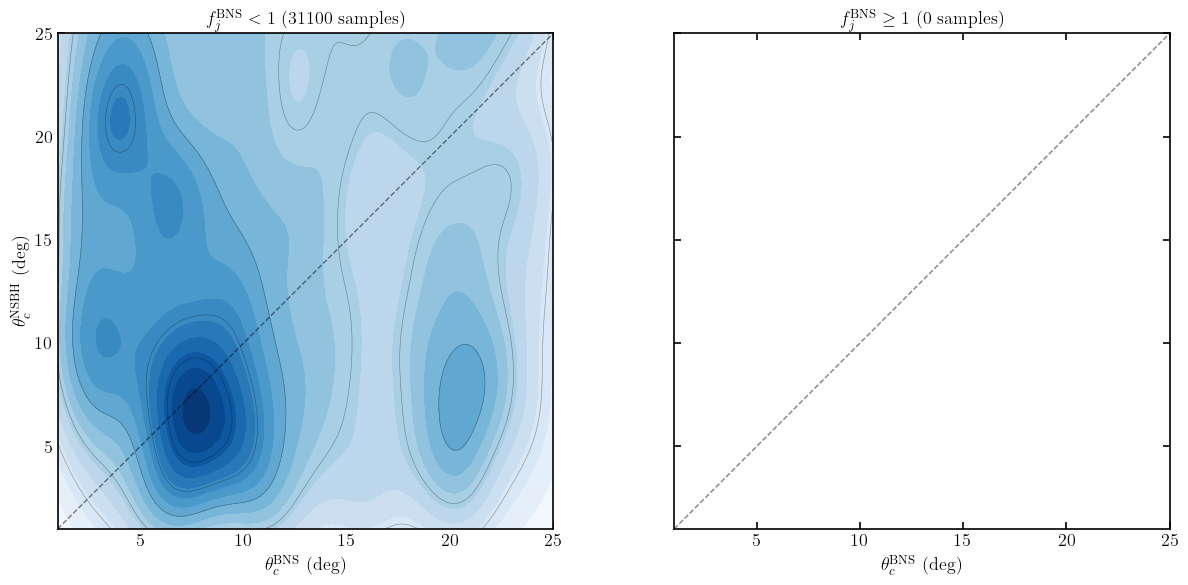

In [19]:
# ── Rate breakdown from posterior samples ───────────────────────────────────
theta_c_bns_post  = flat_samples[:, 4]
theta_c_nsbh_post = flat_samples[:, 5]
fj_bns_post       = flat_samples[:, 6]

from scipy.stats import gaussian_kde

mask_lo = fj_bns_post < 1
mask_hi = ~mask_lo

fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharey=True)

theta_grid = np.linspace(1, 25, 150)
T_BNS, T_NSBH = np.meshgrid(theta_grid, theta_grid)
positions = np.vstack([T_BNS.ravel(), T_NSBH.ravel()])
 
for ax, mask, title, cmap in zip(
    axes,
    [mask_lo, mask_hi],
    [r"$f_j^{\rm BNS} < 1$", r"$f_j^{\rm BNS} \geq 1$"],
    ['Blues', 'Reds'],
):
    pts = np.vstack([theta_c_bns_post[mask], theta_c_nsbh_post[mask]])
    if pts.shape[1] > 10:
        kde = gaussian_kde(pts)
        Z = kde(positions).reshape(T_BNS.shape)
        ax.contourf(T_BNS, T_NSBH, Z, levels=15, cmap=cmap)
        ax.contour(T_BNS, T_NSBH, Z, levels=5, colors='k', linewidths=0.4, alpha=0.4)
    ax.plot([1, 25], [1, 25], 'k--', lw=1, alpha=0.5)
    ax.set_xlabel(r"$\theta_c^{\rm BNS}$ (deg)")
    ax.set_xlim(1, 25)
    ax.set_ylim(1, 25)
    ax.set_aspect('equal')
    ax.set_title(f"{title}  ({mask.sum()} samples)", fontsize=13)

axes[0].set_ylabel(r"$\theta_c^{\rm NSBH}$ (deg)")

plt.tight_layout()
fig.savefig(output_dir / "nsbh_analysis.pdf", dpi=300, bbox_inches='tight')
plt.show()

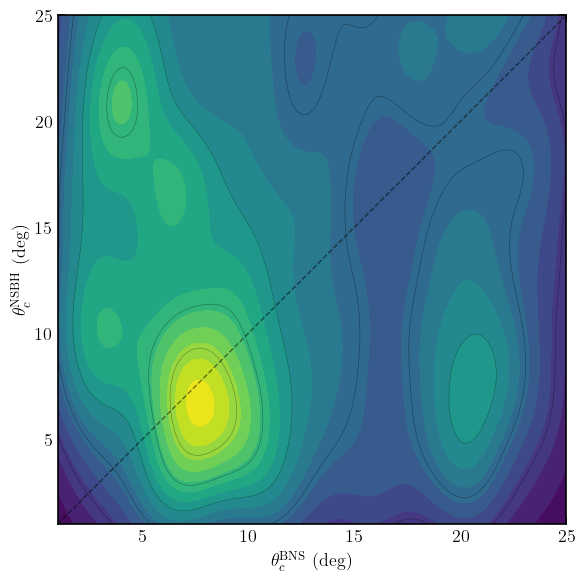

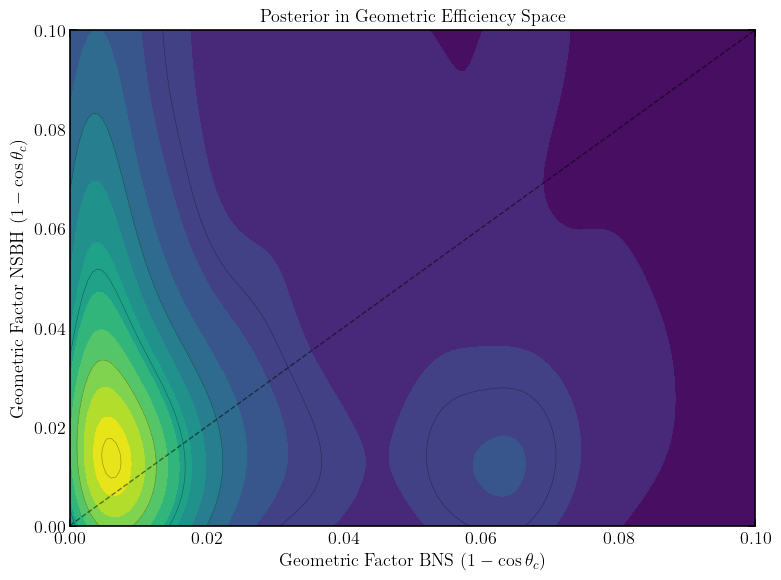

In [ ]:
# ── Rate breakdown from posterior samples ───────────────────────────────────
theta_c_bns_post  = flat_samples[:, 4]
theta_c_nsbh_post = flat_samples[:, 5]
fj_bns_post       = flat_samples[:, 6]

from scipy.stats import gaussian_kde


fig, axes = plt.subplots(figsize=(13, 6), sharey=True)

theta_grid = np.linspace(1, 25, 150)
T_BNS, T_NSBH = np.meshgrid(theta_grid, theta_grid)
positions = np.vstack([T_BNS.ravel(), T_NSBH.ravel()])

pts = np.vstack([theta_c_bns_post, theta_c_nsbh_post])
kde = gaussian_kde(pts)
Z = kde(positions).reshape(T_BNS.shape)
axes.contourf(T_BNS, T_NSBH, Z, levels=15, cmap='viridis')
axes.contour(T_BNS, T_NSBH, Z, levels=5, colors='k', linewidths=0.4, alpha=0.4)
axes.plot([1, 25], [1, 25], 'k--', lw=1, alpha=0.5)
axes.set_xlabel(r"$\theta_c^{\rm BNS}$ (deg)")
axes.set_xlim(1, 25)
axes.set_ylim(1, 25)
axes.set_aspect('equal')
axes.set_ylabel(r"$\theta_c^{\rm NSBH}$ (deg)")

plt.tight_layout()
fig.savefig(output_dir / "nsbh_analysis.pdf", dpi=300, bbox_inches='tight')
plt.show()


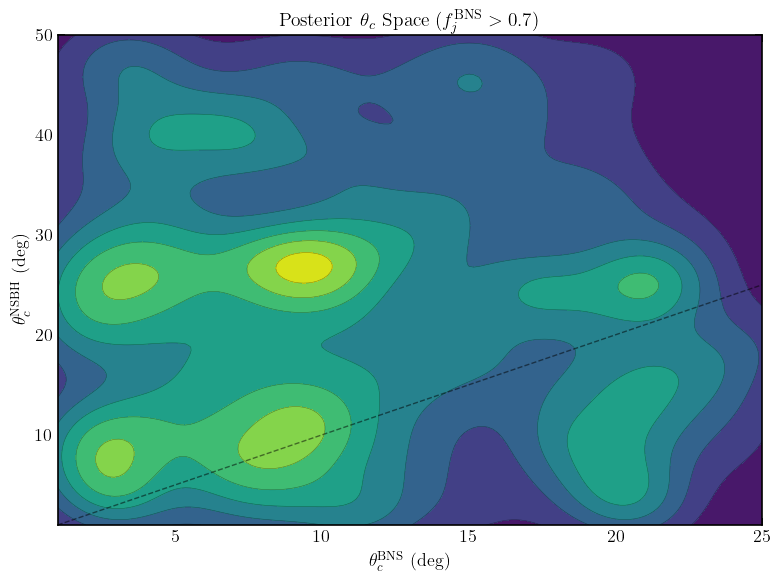

In [24]:
# ── Rate breakdown from posterior samples (f_j > 0.7) ──────────────────────
theta_c_bns_post  = flat_samples[:, 4]
theta_c_nsbh_post = flat_samples[:, 5]
fj_bns_post       = flat_samples[:, 6]

# 1. Create the mask
mask_fj = fj_bns_post > 0.7

# 2. Filter the angles
theta_c_bns_masked  = theta_c_bns_post[mask_fj]
theta_c_nsbh_masked = theta_c_nsbh_post[mask_fj]

from scipy.stats import gaussian_kde

fig, ax = plt.subplots(figsize=(8, 6))

# (Optional: change to 50 if you want to see the full NSBH prior range rather than cropping at 25)
bns_grid = np.linspace(1, 25, 150)
nsbh_grid = np.linspace(1, 50, 150) 
T_BNS, T_NSBH = np.meshgrid(bns_grid, nsbh_grid)
positions = np.vstack([T_BNS.ravel(), T_NSBH.ravel()])

pts = np.vstack([theta_c_bns_masked, theta_c_nsbh_masked])

if pts.shape[1] > 10:  # Ensure we have enough samples to run KDE
    kde = gaussian_kde(pts)
    Z = kde(positions).reshape(T_BNS.shape)
    
    ax.contourf(T_BNS, T_NSBH, Z, levels=7, cmap='viridis')
    ax.contour(T_BNS, T_NSBH, Z, levels=7, colors='k', linewidths=0.4, alpha=0.4)

ax.plot([1, 25], [1, 25], 'k--', lw=1, alpha=0.5)

ax.set_xlabel(r"$\theta_c^{\rm BNS}$ (deg)", fontsize=13)
ax.set_ylabel(r"$\theta_c^{\rm NSBH}$ (deg)", fontsize=13)
ax.set_xlim(1, 25)
ax.set_ylim(1, 50)  # Changed to 50 so it respects the upper bound of your NSBH prior
ax.set_title(r"Posterior $\theta_c$ Space ($f_j^{\rm BNS} > 0.7$)", fontsize=14)

plt.tight_layout()
fig.savefig(output_dir / "nsbh_analysis_fj07.pdf", dpi=300, bbox_inches='tight')
plt.show()

## 12. Comparison: Universal Angle vs Lognormal

If the lognormal MCMC has already been run, load those results and compare the posteriors side by side.

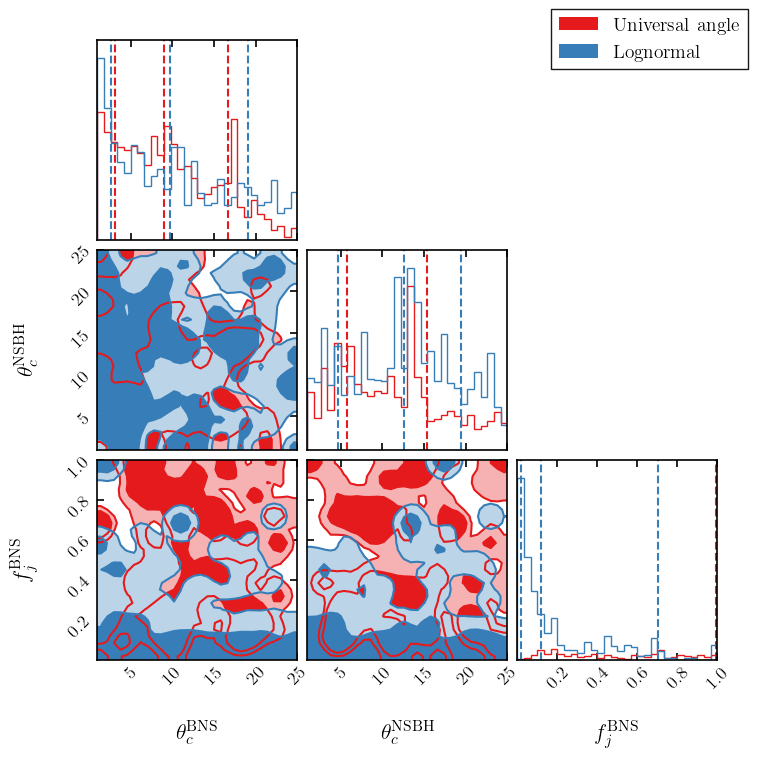


Comparison of key parameters (median [16%, 84%]):
                                      Universal                  Lognormal
  $\theta_{c}^{\mathrm{BNS}}$    9.044 [3.151, 16.662]    9.712 [2.588, 19.090]
  $\theta_{c}^{\mathrm{NSBH}}$   15.367 [5.800, 40.278]   12.578 [4.677, 19.412]
  $f_j^{\mathrm{BNS}}$    3.255 [0.996, 6.649]    0.120 [0.020, 0.702]


In [ ]:
# ── Try to load lognormal results for comparison ────────────────────────────
ln_backend_path = Path("Output_files/NSBH_combined_LN/emcee.h5")

if ln_backend_path.exists():
    ln_backend = emcee.backends.HDFBackend(ln_backend_path)
    ln_burn = ln_backend.iteration // 3
    ln_flat = ln_backend.get_chain(discard=ln_burn, thin=15, flat=True)

    fig = corner.corner(
        flat_samples[:, 4:],
        labels=PARAM_NAMES[4:],
        range=ranges[4:],
        quantiles=[0.16, 0.5, 0.84],
        show_titles=False,
        label_kwargs={"fontsize": 16},
        levels=[0.68, 0.95],
        plot_datapoints=False,
        plot_density=False,
        fill_contours=True,
        bins=30,
        smooth=1.2,
        color=col[0],
    )

    corner.corner(
        ln_flat[:, 4:],
        labels=PARAM_NAMES[4:],
        range=ranges[4:],
        quantiles=[0.16, 0.5, 0.84],
        show_titles=False,
        levels=[0.68, 0.95],
        plot_datapoints=False,
        plot_density=False,
        fill_contours=True,
        bins=30,
        smooth=1.2,
        color=col[1],
        fig=fig,
    )

    # Custom legend
    from matplotlib.patches import Patch
    fig.legend(
        handles=[Patch(facecolor=col[0], label='Universal angle'),
                 Patch(facecolor=col[1], label='Lognormal')],
        loc='upper right', fontsize=14,
    )
    fig.savefig(output_dir / "comparison_corner.pdf", dpi=300, bbox_inches='tight')
    plt.show()

    # Compare rates
    print("\nComparison of key parameters (median [16%, 84%]):")
    print(f"{'':>20s}  {'Universal':>25s}  {'Lognormal':>25s}")
    for i, label in enumerate(PARAM_NAMES[4:]):
        idx = i + 4
        lo_u, med_u, hi_u = np.percentile(flat_samples[:, idx], [16, 50, 84])
        lo_l, med_l, hi_l = np.percentile(ln_flat[:, idx], [16, 50, 84])
        print(f"  {label:>18s}  {med_u:7.3f} [{lo_u:.3f}, {hi_u:.3f}]  "
              f"{med_l:7.3f} [{lo_l:.3f}, {hi_l:.3f}]")
else:
    print(f"Lognormal results not found at {ln_backend_path}")
    print("Run the lognormal notebook first, then re-run this cell for comparison.")